# Decision Tree (CART) from Scratch	
### Gini impurity, entropy, recursive split, pruning

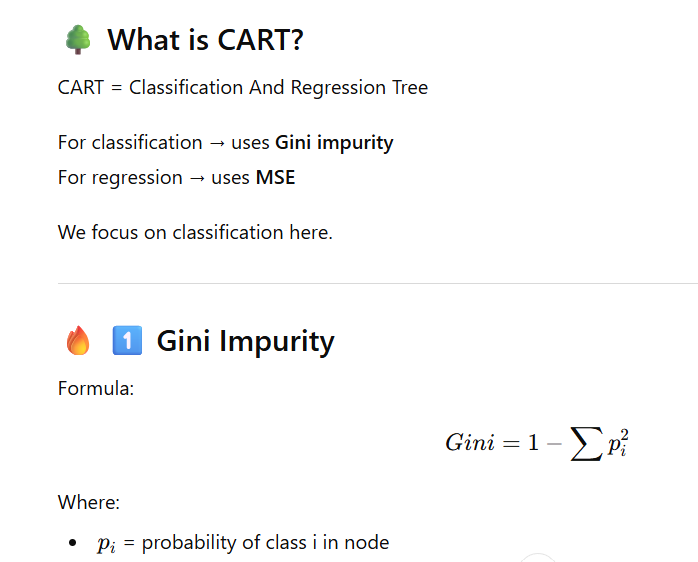

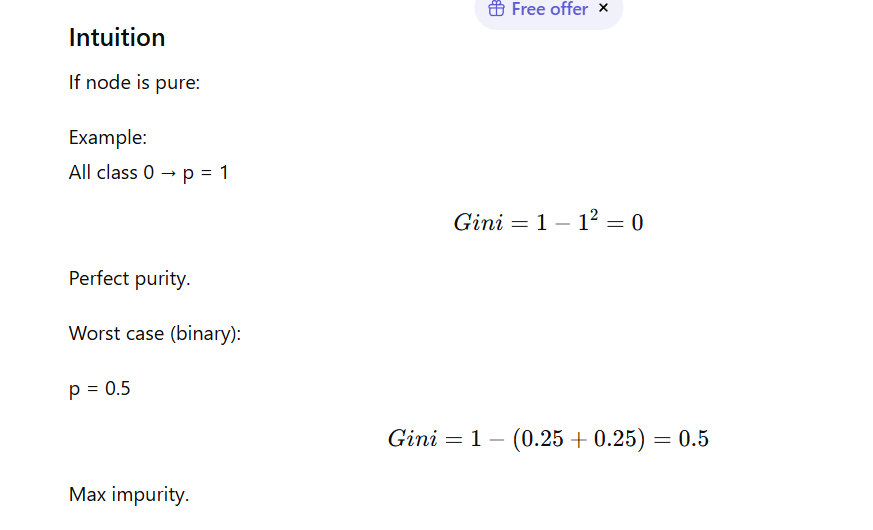

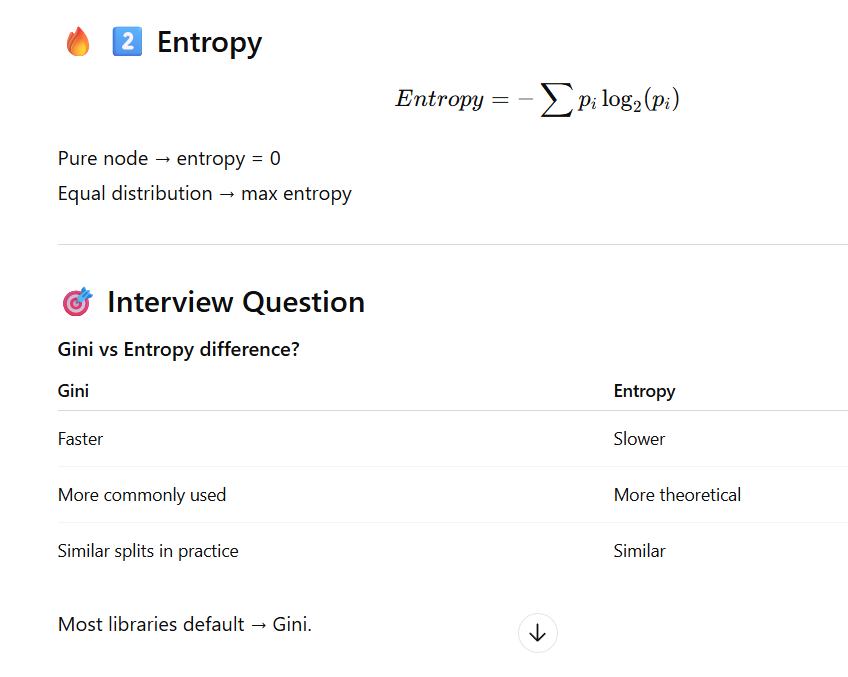

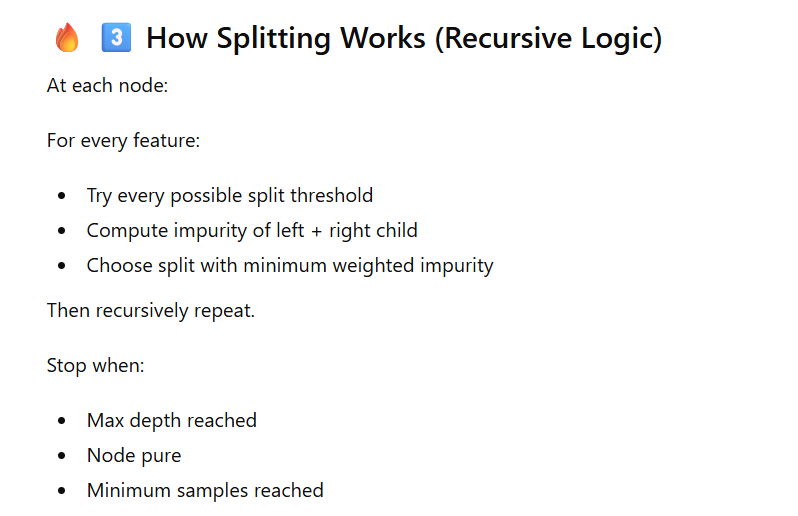

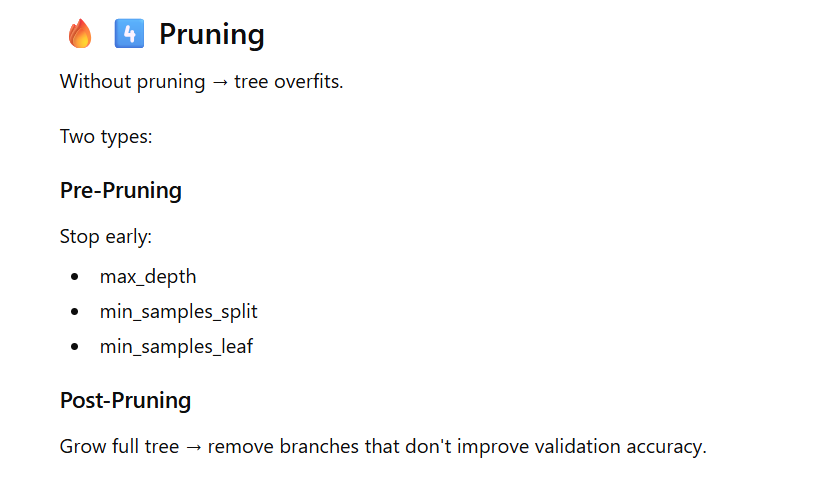

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [8]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    def gini(self, y):
        classes = np.unique(y)
        impurity = 1
        for cls in classes:
            p = np.sum(y == cls)/len(y)
            impurity -= p ** 2
        return impurity
    
    def best_split(self, X, y):
        best_feature, best_threshold  = None, None
        best_impurity = float('inf')

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_idx = X[:, feature] <= threshold
                right_idx = X[:, feature] > threshold

                if len(y[left_idx]) == 0 or len(y[right_idx]) == 0:
                    continue

                left_impurity = self.gini(y[left_idx])
                right_impurity = self.gini(y[right_idx])

                weighted_impurity = (
                    len(y[left_idx]) / len(y) * left_impurity + len(y[right_idx]) / len(y) * right_impurity 
                )

                if weighted_impurity < best_impurity:
                    best_impurity = weighted_impurity
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold
    
    def build_tree(self, X, y, depth=0):
        if (depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < self.min_samples_split):
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)

        feature, threshold = self.best_split(X, y)
        if feature is None:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)
            
        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold

        left = self.build_tree(X[left_idx], y[left_idx], depth+1)
        right = self.build_tree(X[right_idx], y[right_idx], depth+1)

        return Node(feature, threshold, left, right)
    
    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    def predict_sample(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self.predict_sample(x, node.left)
        return self.predict_sample(x, node.right)
            
    def predict(self, X):
        return np.array([self.predict_sample(x, self.tree) for x in X])



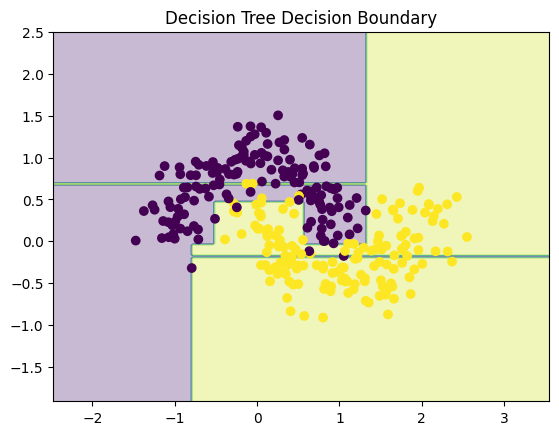

In [9]:
# Generate dataset
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

tree = DecisionTree(max_depth=5)
tree.fit(X, y)

# Plot decision boundary
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = tree.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Decision Tree Decision Boundary")
plt.show()